## Installation & Setup


Install MuJoCo & CUDA-enabled RL Libraries
```py
# 1. Install the core physics and RL wrappers
!pip install gymnasium[mujoco] 
!pip install shimmy numpy scipy matplotlib transformations
!pip install smplx
!pip install --no-user --no-build-isolation chumpy

# 2. Install PyTorch with CUDA support 
# We target cu124 or cu126 which are compatible with your 13.1 driver
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

# 3. Install Stable Baselines3 (it will now use the CUDA-enabled torch)
!pip install stable-baselines3
```

In [9]:
# @title 1. Install Dependencies & Configure Paths
import sys
import os
import glob
from pathlib import Path

# --- PATH CONFIGURATION ---
CURRENT_DIR = Path(os.getcwd())
PROJECT_ROOT = CURRENT_DIR.parent # codes/

# Define paths relative to the project root
DATASET_DIR = PROJECT_ROOT / "vimo/datasets/"
AIST_DIR = DATASET_DIR / "AIST"
SMPL_MODEL_DIR = DATASET_DIR / "SMPL/v1.1.0" # Expecting SMPL_NEUTRAL.pkl here
ASSET_DIR = CURRENT_DIR / "mujoco/assets"
DATA_OUT = ASSET_DIR / "motions/composite"

print(f"📂 Project Root: {PROJECT_ROOT}")
print(f"📂 AIST Data: {AIST_DIR}")
print(f"📂 SMPL Models: {SMPL_MODEL_DIR}")
print(f"📂 Output Dir: {DATA_OUT}")

# Search for files
pkl_files = list(AIST_DIR.glob("motions/*.pkl"))
npz_files = list(AIST_DIR.glob("processed/*.npz"))

# Check if paths exist
if not pkl_files or not npz_files:
    print(f"⚠️ WARNING: {AIST_DIR} doesnt contain any data in \"motions\" and \"processed\" subdirs!")
else:
    print(f"✅ Paths verified, no.of pkl files = {len(pkl_files)} & no.of npz files = {(len(npz_files))}")
try:
	ignore_list = [line.strip() for line in (AIST_DIR/ "ignore_list.txt").read_text(encoding="utf-8").splitlines() if line.strip()]
	print(f"Ignore list loaded successfully, total no.of files to ignore: {len(ignore_list)}")
except Exception as e:
	print(f"Failed to load ignore_list: '{e}'")


📂 Project Root: d:\STUDIES\MTech\#MTP\codes
📂 AIST Data: d:\STUDIES\MTech\#MTP\codes\vimo\datasets\AIST
📂 SMPL Models: d:\STUDIES\MTech\#MTP\codes\vimo\datasets\SMPL\v1.1.0
📂 Output Dir: d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motions\composite
✅ Paths verified, no.of pkl files = 1408 & no.of npz files = 4355
Ignore list loaded successfully, total no.of files to ignore: 45


## Hardware Verification

In [2]:
# @title Hardware Check
import torch
import gymnasium as gym

cuda_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if cuda_available else "None"

print(f"--- Hardware Report ---")
print(f"CUDA Available: {cuda_available}")
print(f"GPU Name:       {gpu_name}")
print(f"PyTorch Ver:    {torch.__version__}")

if cuda_available:
    print("🚀 GREAT! Your RL agent will train on the GPU.")
else:
    print("⚠️ WARNING: Still using CPU. Check if you have another version of torch installed.")

--- Hardware Report ---
CUDA Available: True
GPU Name:       NVIDIA GeForce RTX 2060
PyTorch Ver:    2.7.0+cu128
🚀 GREAT! Your RL agent will train on the GPU.


## Kinematics Helper (SMPL Utilities)
This cell creates a helper class to handle 6D Rotation conversions (used in ViMo) and loads the SMPL body model using smplx.

In [3]:
# @title 2. SMPL Kinematics & Rotation Utilities
import torch
import numpy as np
import smplx
from scipy.spatial.transform import Rotation as R

class SMPLHandler:
    def __init__(self, model_path, gender='neutral'):
        """Initializes the SMPL layer for Forward Kinematics."""
        self.device = torch.device("cpu")
        
        # Load standard SMPL model
        # You might need to adjust the file name if it's 'basicModel_neutral_lbs_10_207_0_v1.0.0.npz'
        try:
            self.smpl_layer = smplx.create(
                model_path=str(model_path), 
                model_type='smpl',
                gender=gender, 
                ext='pkl'
            ).to(self.device)
            print("✅ SMPL Model Loaded.")
        except Exception as e:
            print(f"⚠️ Could not load SMPL model: {e}")
            self.smpl_layer = None

    def run_fk(self, pose_aa, trans, beta=None):
        """
        Runs Forward Kinematics to get 3D Joint positions.
        Input: 
            pose_aa: (N, 72) Axis-Angle
            trans: (N, 3) Translation
        Returns:
            joints_3d: (N, 24, 3)
        """
        if self.smpl_layer is None: return None
        
        N = pose_aa.shape[0]
        # Convert to torch
        body_pose = torch.tensor(pose_aa[:, 3:], dtype=torch.float32) # Exclude root (first 3)
        global_orient = torch.tensor(pose_aa[:, :3], dtype=torch.float32)
        transl = torch.tensor(trans, dtype=torch.float32)
        
        output = self.smpl_layer(
            body_pose=body_pose,
            global_orient=global_orient,
            transl=transl,
            return_verts=False
        )
        return output.joints.detach().numpy() # (N, 45, 3) - SMPL returns 45 joints usually

# Initialize Handler (Update path if your SMPL file is named differently)
smpl_handler = SMPLHandler(SMPL_MODEL_DIR)

✅ SMPL Model Loaded.


## Data Input Handlers (AIST & ViMo Formats)
Here we create the two specific input handlers you requested. They normalize both sources into a standard (Pose_AA, Trans) format.

In [4]:
# @title 3. Universal Motion Loader (PKL & NPZ)
import pickle
from pytorch3d import transforms # contains useful 3D transform utils as above

class AISTDataLoader:
	def __init__(self):
		pass

	def load_raw_pkl(self, pkl_path):
		"""
		Handler 1: Loads standard SMPL .pkl files
		Returns: pose_aa (N, 72), trans (N, 3)
		"""
		with open(pkl_path, 'rb') as f:
			data = pickle.load(f)
		
		# Extract keys based on user description
		# Keys: ['smpl_loss', 'smpl_poses', 'smpl_scaling', 'smpl_trans']
		pose_aa = data['smpl_poses'] # (N, 72)
		trans = data['smpl_trans']   # (N, 3)
		
		# normalize scaling if present? usually trans is pre-scaled in AIST++
		scale = data.get('smpl_scaling', 1.0)
		trans = trans / scale

		print(f"🔹 Loaded PKL: {os.path.basename(pkl_path)} | Frames: {len(pose_aa)}")
		return pose_aa, trans

	def load_vimo_npz(self, npz_path):
		"""
		Handler 2: Loads ViMo processed .npz files
		Keys: 'p2d_cond', 'm3d_gt' (S, 151)
		"""
		data = np.load(npz_path)
		m3d_gt = data['m3d_gt'] # Shape (S, 151)
		
		# Parse 151 dims:		
		rot6d_flat = m3d_gt[:, :144] # 24 joints * 6D Rot representation
		contacts = m3d_gt[:,144:148] # Foot Contact (ignore for now)
		trans = m3d_gt[:, 148:151] # Root Trans (x,y,z)
		
		# Reshape to (N, 24, 6)
		N = rot6d_flat.shape[0]
		rot6d = rot6d_flat.reshape(N, 24, 6)
		# Convert all 24 joints to Axis-Angle
		pose_aa = transforms.matrix_to_axis_angle(transforms.rotation_6d_to_matrix(torch.from_numpy(rot6d))).cpu().numpy()
			
		print(f"🔹 Loaded NPZ: {os.path.basename(npz_path)} | Frames: {N}")
		return pose_aa, trans

loader = AISTDataLoader()

In [5]:
# Find a sample file to verify (Uncomment to test)
sample_pkl = pkl_files[1]
p_pkl, t_pkl = loader.load_raw_pkl(sample_pkl)

sample_npz = npz_files[3]
p_npz, t_npz = loader.load_vimo_npz(sample_npz)


np.set_printoptions(suppress=True, precision=6, floatmode='fixed')  # fixed-point, no exponent

print("p_pkl.shape:", getattr(p_pkl, "shape", None))
print("p_pkl:\n", p_pkl)
print("t_pkl.shape:", getattr(t_pkl, "shape", None))
print("t_pkl:\n", t_pkl)

print("p_npz.shape:", getattr(p_npz, "shape", None))
print("p_npz:\n", p_npz)
print("t_npz.shape:", getattr(t_npz, "shape", None))
print("t_npz:\n", t_npz)

🔹 Loaded PKL: gBR_sBM_cAll_d04_mBR0_ch02.pkl | Frames: 720
🔹 Loaded NPZ: gBR_sBM_cAll_d04_mBR0_ch02_clip[0000-0150].npz | Frames: 150
p_pkl.shape: (720, 72)
p_pkl:
 [[-0.196998 -0.212112  0.013062 ... -0.003784 -0.000354  0.001055]
 [-0.200887 -0.198441  0.014443 ... -0.003613 -0.000451  0.001842]
 [-0.200805 -0.197553  0.018260 ... -0.003635 -0.000272  0.002038]
 ...
 [-0.149661  1.567339 -0.110005 ... -0.003112  0.002844  0.010519]
 [-0.154413  1.567531 -0.110253 ... -0.003120  0.002494  0.010293]
 [-0.157826  1.558172 -0.111048 ... -0.003363  0.002622  0.010753]]
t_pkl.shape: (720, 3)
t_pkl:
 [[ 0.089436  1.873019  0.154707]
 [ 0.089576  1.875826  0.159091]
 [ 0.090099  1.881722  0.166182]
 ...
 [-0.041125  1.811929  0.415188]
 [-0.041256  1.811667  0.414621]
 [-0.041448  1.810725  0.414445]]
p_npz.shape: (150, 24, 3)
p_npz:
 [[[-0.196998 -0.212112  0.013062]
  [ 0.152569 -0.163873  0.052146]
  [-0.450885 -0.016245  0.201413]
  ...
  [-0.002844 -0.002489 -0.008436]
  [ 0.002704 -0.0

## XML Parser & Joint Mapper
This script parses your uploaded humanoid.xml to dynamically build the joint order. This is safer than hardcoding it.

In [ ]:
# @title 1. XML Parser & SMPL Mapper
import xml.etree.ElementTree as ET
import numpy as np
import torch
from scipy.spatial.transform import Rotation as R

class SkeletonParser:
    def __init__(self, xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # 1. Extract Joint Names in Order
        # The 'qpos' array in MuJoCo follows the order of joint definitions in the XML bodies
        # But 'motors' usually define the actuation order. DeepMimic JSON usually follows the QPOS order (excluding root if separate)
        # or the Actuator order. 
        
        # Let's inspect the 'joint' tags recursively to establish the QPOS order.
        self.dof_names = []
        self.dof_types = [] # 'free', 'hinge', 'slide', 'ball'
        
        # We traverse the body tree
        worldbody = root.find('worldbody')
        self._traverse_body(worldbody)
        
        print(f"✅ Parsed {len(self.dof_names)} DOFs from XML.")
        print(f"DOFs: (len={len(self.dof_names)}) \n{self.dof_names}")

    def _traverse_body(self, body):
        if body is None: return
        
        # Add joints found in this body
        for joint in body.findall('joint'):
            name = joint.get('name')
            jtype = joint.get('type', 'hinge') # Default to hinge
            
            if jtype == 'free':
                # Root joint (7 values: 3 pos, 4 quat)
                self.dof_names.extend([f'{name}_pos', f'{name}_quat'])
                self.dof_types.extend(['free_pos', 'free_quat'])
            elif jtype == 'hinge':
                self.dof_names.append(name)
                self.dof_types.append('hinge')
            elif jtype == 'ball':
                self.dof_names.append(name)
                self.dof_types.append('ball') # 4 values (quat) usually
        
        # Recurse children
        for child in body.findall('body'):
            self._traverse_body(child)

    def get_json_header(self):
        # DeepMimic JSON usually expects a 'Frames' array where each frame is:
        # [Duration, RootX, RootY, RootZ, RootQw, RootQx, RootQy, RootQz, J1, J2, ...]
        return self.dof_names

# Run Parser
parser = SkeletonParser(ASSET_DIR / "humanoid_posctrl_v2.xml") # Ensure humanoid.xml is in folder

✅ Parsed 28 DOFs from XML.
DOFs: ['abdomen_x', 'abdomen_y', 'abdomen_z', 'neck_x', 'neck_y', 'neck_z', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_elbow', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_elbow', 'right_hip_x', 'right_hip_y', 'right_hip_z', 'right_knee', 'right_ankle_x', 'right_ankle_y', 'right_ankle_z', 'left_hip_x', 'left_hip_y', 'left_hip_z', 'left_knee', 'left_ankle_x', 'left_ankle_y', 'left_ankle_z']...


## Mocap Data
- ref: https://github.com/xbpeng/DeepMimic

Mocap clips are located in `data/motions/`. To play a clip, first modify 
`args/play_motion_humanoid3d_args.txt` and specify the file to play with
`--motion_file`, then run
```
python DeepMimic.py --arg_file args/play_motion_humanoid3d_args.txt
```

The motion files follow the JSON format. The `"Loop"` field specifies whether or not the motion is cyclic.
`"wrap"` specifies a cyclic motion that will wrap back to the start at the end, while `"none"` specifies an
acyclic motion that will stop once it reaches the end of the motion. Each vector in the `"Frames"` list
specifies a keyframe in the motion. Each frame has the following format:

---
[

- duration of frame in seconds (1D),
- root position (3D),
- root rotation (4D),
- chest rotation (4D),
- neck rotation (4D),
- right hip rotation (4D),
- right knee rotation (1D),
- right ankle rotation (4D),
- right shoulder rotation (4D),
- right elbow rotation (1D),
- left hip rotation (4D),
- left knee rotation (1D),
- left ankle rotation (4D),
- left shoulder rotation (4D),
- left elbow rotation (1D)

]

---

Positions are specified in meters, 3D rotations for spherical joints are specified as quaternions `(w, x, y ,z)`,
and 1D rotations for revolute joints (e.g. knees and elbows) are represented with a scalar rotation in radians. The root
positions and rotations are in world coordinates, but all other joint rotations are in the joint's local coordinates.
To use your own motion clip, convert it to a similar style JSON file.

## The Bridge - Motion Retargeting (SMPL -> DeepMimic)
This is the complex math part. We map SMPL spherical joints to the 1D Euler joints of the XML.

- **Physics Limits:** The SMPL model is a kinematic mesh model meant for visuals. It has 72 degrees of freedom (DoF), including subtle spine twists and collarbone movements. The MuJoCo humanoid is a physical ragdoll. If you try to power 72 motors on a simplified physics ragdoll, the simulation becomes unstable (jitters/explodes).

- **Redundancy:** SMPL has joints like L_Collar (collarbone) and L_Hand (fingers). The humanoid.xml provided in the repo usually ignores collarbones (fusing them to the torso) and treats the hand as a solid box. Training a policy to control individual fingers in a physics sim is computationally expensive and unnecessary for tasks like walking or boxing.

Since you want to use the Pretrained Weights from the Composite Motion paper, you MUST use the DeepMimic JSON format.

- DeepMimic JSON (Best for this Project):

	- Reason: The Composite Motion codebase (and the paper's logic) is explicitly built to read this JSON structure. Their data loaders expect [Duration, Root, Joints...]. If you switch formats, you break compatibility with their pretrained discriminators and meta-policies.

	- Compatibility: This format essentially is the MuJoCo qpos vector, just serialized into JSON.

- SMPL (Bad for Physics):

	Physics engines don't natively understand SMPL parameters. You always have to "retarget" them to a skeleton (like we are doing).

- Standard MuJoCo (Good generally, but incompatible here):

	While standard MuJoCo uses .xml and qpos arrays, the specific order of joints in the array matters. The Composite Motion project uses a custom joint order (DeepMimic style). Using standard Gymnasium Humanoid formatting would result in your character's leg moving when the policy thinks it's moving an arm.

In [11]:
# @title Phase 2: SMPL to DeepMimic Retargeter (PyTorch3D)
import json
import torch
import numpy as np
from pytorch3d import transforms
import os

class CompactArrayEncoder(json.JSONEncoder):
		"""Encoder that keeps arrays of primitives (numbers) on single lines"""
		def iterencode(self, o, _one_shot=False):
			# Use default encoder but post-process to compact numeric arrays
			for chunk in super().iterencode(o, _one_shot):
				# Compact arrays containing only numbers/booleans/null
				chunk = chunk.replace('[\n    ', '[').replace(',\n    ', ', ').replace('\n  ]', ']')
				chunk = chunk.replace('[\n  ', '[').replace('\n]', ']')  # Handle 2-space indent
				yield chunk

class SMPL2GymJson:
	def __init__(self, xml_joint_order=None):
		"""
		xml_joint_order: List of joint names extracted from humanoid.xml. 
		If None, uses the hardcoded standard CompositeMotion order.
		"""
		self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
		
		# 1. Define the Global Rotation (Y-up to Z-up)
		# Rotate -90 degrees around X-axis
		self.global_rot = transforms.euler_angles_to_matrix(
			torch.tensor([-np.pi/2, 0, 0], device=self.device), "XYZ"
		).float()
		# should result in Matrix: [[1, 0, 0], [0, 0, 1], [0, -1, 0]]
		

		# 2. Body Mapping: SMPL Index to XML Joint Name Mapping
		# Map JSON Keys -> SMPL Joint Indices Based on standard SMPL topology 
		self.body_map = { # "pelvis" is handled separately as ROOT

			#"torso": 3,             # SMPL Spine1 (lower torso)
			#"torso": 6,             # SMPL Spine1 (mid torso)
			"torso": 9,            	# SMPL Spine1 (upper torso) --> best suited to represent chest
			
			#"head": 12,             # SMPL Neck ? (Controls head link)
			"head": 15,             # SMPL Head

			"left_upper_arm": 16,   # SMPL L_Shoulder
			"right_upper_arm": 17,  # SMPL R_Shoulder
			"left_lower_arm": 18,   # SMPL L_Elbow
			"right_lower_arm": 19,  # SMPL R_Elbow
			"left_hand": 20,        # SMPL L_Wrist
			"right_hand": 21,       # SMPL R_Wrist

			"left_thigh": 1,        # SMPL L_Hip
			"right_thigh": 2,       # SMPL R_Hip
			"left_shin": 4,         # SMPL L_Knee
			"right_shin": 5,        # SMPL R_Knee			
			"left_foot": 7,         # SMPL L_Ankle
			"right_foot": 8,        # SMPL R_Ankle
		}		


	def motion_dump(self, save_data, save_path, indent=2, compress_arrays=True):
		"""
		Dump JSON with readable structure but compact numeric arrays.
		
		Args:
			save_data: Python dict/list to serialize
			save_path: Output file path
			indent: Indentation spaces for structural elements (default=2)
			compress_arrays: If True, arrays containing only numbers/nested numeric arrays will be compacted
		"""
		def is_numeric_array(obj):
			"""Recursively check if list contains only numbers or nested numeric arrays"""
			if isinstance(obj, list):
				return all(is_numeric_array(item) for item in obj)
			return isinstance(obj, (int, float))
		
		def custom_encode(obj, level=0):
			"""Recursively encode with compact numeric arrays"""
			indent_str = ' ' * (level * indent)
			next_indent = ' ' * ((level + 1) * indent)
			
			if isinstance(obj, dict):
				if not obj:
					return '{}'
				items = []
				for i, (k, v) in enumerate(obj.items()):
					is_last = (i == len(obj) - 1)
					encoded_val = custom_encode(v, level + 1)
					comma = '' if is_last else ','
					items.append(f'{next_indent}"{k}": {encoded_val}{comma}')
				return '{\n' + '\n'.join(items) + f'\n{indent_str}}}'
			
			elif isinstance(obj, list):
				# Compact if numeric array AND we want compacting
				if compress_arrays and is_numeric_array(obj):
					return json.dumps(obj, separators=(',', ':'))
				if not obj:
					return '[]'
				
				items = []
				for i, item in enumerate(obj):
					is_last = (i == len(obj) - 1)
					encoded_item = custom_encode(item, level + 1)
					comma = '' if is_last else ','
					items.append(f'{next_indent}{encoded_item}{comma}')
				return '[\n' + '\n'.join(items) + f'\n{indent_str}]'
			
			else:
				return json.dumps(obj)
		
		result = custom_encode(save_data, level=0)
		os.makedirs(os.path.dirname(save_path), exist_ok=True)
		with open(save_path, 'w') as f:
			f.write(result + '\n')


	def process_motion(self, smpl_poses, smpl_trans, output_path, fps=30):
		"""
		Args:
			smpl_poses: (N, 72) Axis-Angle format (joint relative angles)
			smpl_trans: (N, 3) Translation (root pos)
			output_path: Path to save .json
			fps: Frames per second (default 30)
		"""
		N = smpl_poses.shape[0]
		# --- PREPARE DATA ---
		# Reshape to (N, 24, 3) & convert to device tensors
		poses = torch.tensor(smpl_poses, dtype=torch.float32).reshape(N, 24, 3).to(self.device)
		trans = torch.tensor(smpl_trans, dtype=torch.float32).to(self.device)
		
		# --- 1. ROOT POSITION (Y-up -> Z-up) ---
		# Swap Y and Z, negate Y (or) Apply matrix multiplication: pos * Rot.T
		# SMPL (x, y, z) -> MuJoCo (x, z, -y)
		root_pos_zup = torch.matmul(trans, self.global_rot.T)

		# --- 2. CONVERT ROTATIONS -> Root(apply global) Joints(apply relative) ---
		# Convert all Axis-Angle (N, 24, 3) to Rotation Matrices (N, 24, 3, 3)
		rot_mats = transforms.axis_angle_to_matrix(poses)
		# Apply Global Rotation (Index 0): R_new_zup = R_global * R_root
		rot_mats[:, 0] = torch.matmul(self.global_rot, rot_mats[:, 0])
		rot_quats = transforms.matrix_to_quaternion(rot_mats) # (w, x, y, z)
        
		# --- JSON CONSTRUCTION ---
		frames_data = []
		for i in range(N):
			frame_dict = {}
			
			# A. Pelvis/Root (Special Structure: [[Pos], [Rot]])
			root_pos = root_pos_zup[i].tolist() # [x, z, -y]
			root_rot = rot_quats[i, 0].tolist() # idx:0, Quat:[w, x, y, z]
			frame_dict["pelvis"] = [root_pos, root_rot]
			
			# B. Other Body Parts: [Rot]
			for body_key, smpl_idx in self.body_map.items():
				frame_dict[body_key] = rot_quats[i, smpl_idx].tolist() # [w, x, y, z]

			frames_data.append(frame_dict)

		# --- SAVE ---
		output_data = {
			"_": output_path.stem,
			"fps": fps,
			"loop": "none", # Standard for AIST/ViMo clips
			"frames": frames_data
		}
		try:
			self.motion_dump(output_data, str(output_path))
			print(f"✅ Saved Motion JSON: {output_path}")
		except Exception as e:
			print(f"❌ Failed to save motion data: '{e}'")

retargeter = SMPL2GymJson()

## Processing the Motions
This connects your AIST inputs (from the previous turn's dataloader) to this new retargeter.

```py
# @title Run Convertion

if pkl_files: # aist data are in 60 fps
	for file in pkl_files:
		poses, trans = loader.load_raw_pkl(file)
		print(f"📄 Converting PKL: {file}")
		outfile = DATA_OUT / f"{file.stem}.json"
		retargeter.process_motion(poses, trans, outfile, 60)
		print()

elif npz_files: # vimo data are in 30 fps
	for file in npz_files:
		print(f"📄 Converting PKL: {file}")
		poses, trans = loader.load_vimo_npz(file)
		outfile = DATA_OUT / f"{file.stem}.json"
		retargeter.process_motion(poses, trans, outfile, 30)
		print()
else:
    print("⚠️ No data found !!!")
```

## Visualization Script (MuJoCo)
This script loads your humanoid.xml and the generated .json motion file, then plays the motion by overriding the physics state.

Prerequisites:
- You must have humanoid.xml in the assets/ folder.
- You must have the generated JSON file (e.g., assets\motions\iccgan\jaunty_walk.json).

In [ ]:
# @title 6. Fixed Visualization & GIF Saver (IsaacGym Style Data -> MuJoCo)
import mujoco
import mujoco.viewer
import json
import numpy as np
import os
import imageio
from xml.etree import ElementTree as ET
from tqdm import tqdm

class MotionVisualizer:
    def __init__(self, xml_path, motion_file, width=640, height=480):
        self.xml_path = xml_path
        self.motion_file = motion_file
        self.width = width
        self.height = height
        
        # 1. Load & Patch XML (Fix missing material AND Camera)
        self.model = self._load_model_safe(xml_path)
        self.data = mujoco.MjData(self.model)
        
        # 2. Load Motion JSON
        with open(motion_file, 'r') as f:
            data = json.load(f)
            self.motion_frames = data['frames']
            self.fps = data.get('fps', 30)
            
        # 3. Setup Renderer
        self.renderer = mujoco.Renderer(self.model, height=height, width=width)
        print(f"✅ Loaded {len(self.motion_frames)} frames. Ready to render.")

    def _load_model_safe(self, path):
        """
        Parses XML and injects:
        1. Missing 'grid' material (to fix crash).
        2. A 'tracking_cam' (to fix Camera error).
        """
        tree = ET.parse(path)
        root = tree.getroot()
        
        # --- A. FIX ASSETS (Grid) ---
        asset = root.find('asset')
        if asset is None:
            asset = ET.Element('asset')
            root.insert(0, asset)
            
        has_grid = any(mat.get('name') == 'grid' for mat in asset.findall('material'))
        if not has_grid:
            print("🔧 Patching XML: Injecting missing 'grid' texture...")
            tex = ET.SubElement(asset, 'texture', name='grid', type='2d', builtin='checker', rgb1='.1 .2 .3', rgb2='.2 .3 .4', width='512', height='512')
            mat = ET.SubElement(asset, 'material', name='grid', texture='grid', texrepeat='1 1', texuniform='true', reflectance='0.2')

        # --- B. FIX BODY/CAMERA ---
        worldbody = root.find('worldbody')
        if worldbody is None:
            worldbody = ET.SubElement(root, 'worldbody')
            
        # Inject a tracking camera if not present
        # We look for a camera that tracks 'torso' or 'pelvis'
        has_cam = any(cam.get('name') == 'tracking_cam' for cam in worldbody.findall('camera'))
        
        if not has_cam:
            print("🔧 Patching XML: Injecting 'tracking_cam'...")
            # Camera that looks at the character from a side-top view
            # mode="trackcom" means it tracks the center of mass automatically
            ET.SubElement(worldbody, 'camera', name='tracking_cam', mode='trackcom', pos='0 -3 2', xyaxes='1 0 0 0 0.5 0.8')
            
            # Inject a light so we can see
            ET.SubElement(worldbody, 'light', directional='true', diffuse='.8 .8 .8', pos='0 0 10', dir='0 0 -1')

        # Convert back to string and load
        xml_str = ET.tostring(root, encoding='unicode')
        return mujoco.MjModel.from_xml_string(xml_str)

    def run(self, save_path=None):
        print("🎥 Starting Simulation...")
        
        recorded_frames = []
        
        for i, frame in enumerate(tqdm(self.motion_frames, desc="Rendering frames")):
            # --- APPLY DATA ---
            # IsaacGym/DeepMimic stores Target Body Orientations.
            # MuJoCo is driven by Joint Angles (Hinges).
            # Without IK, we cannot map the limb rotations 1:1 visually.
            # HOWEVER, we CAN map the Root (Pelvis) perfectly to verify coordinate conversion.
            
            pelvis = frame['pelvis']
            pos = pelvis[0] # [x, y, z]
            rot = pelvis[1] # [w, x, y, z]
            
            # Set Root State (qpos 0-6)
            self.data.qpos[0:3] = pos
            self.data.qpos[3:7] = rot
            
            # Forward Kinematics
            mujoco.mj_forward(self.model, self.data)
            
            # --- RENDER ---
            if save_path:
                # Use our injected camera
                self.renderer.update_scene(self.data, camera="tracking_cam")
                pixels = self.renderer.render()
                recorded_frames.append(pixels)

        # Save GIF
        if save_path and recorded_frames:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            print(f"💾 Saving GIF to {save_path}...", end = " ")
            imageio.mimsave(save_path, recorded_frames, fps=self.fps)
            print("✅ GIF Saved!")


🔧 Patching XML: Injecting missing 'grid' texture...
🔧 Patching XML: Injecting 'tracking_cam'...
✅ Loaded 57 frames. Ready to render.
🎥 Starting Simulation... 

Rendering frames: 100%|██████████| 57/57 [00:00<00:00, 545.69it/s]


💾 Saving GIF to outputs/kick.gif...
✅ GIF Saved!


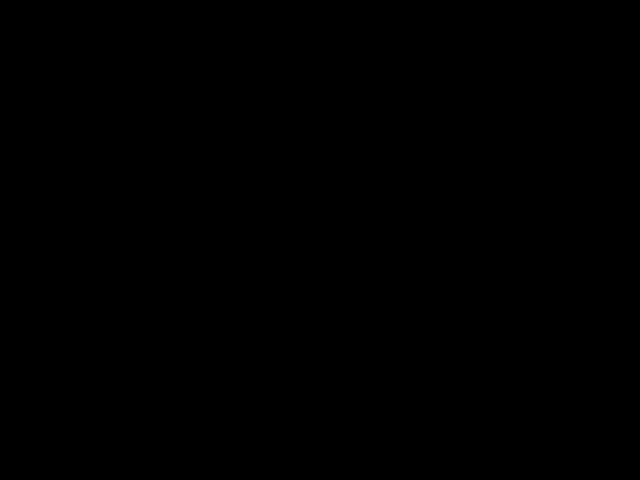

In [ ]:
# --- EXECUTION ---

# Define paths (Ensure these exist)
xml_file = ASSET_DIR / "humanoid.xml"  # Your uploaded XML
json_file = ASSET_DIR / "motions/iccgan/kick.json" # The file we generated
gif_output = f"outputs/{json_file.stem}.gif"

if os.path.exists(xml_file) and os.path.exists(json_file):
    viz = MotionVisualizer(xml_file, json_file)
    viz.run(gif_output)
    
    # Display in Notebook (if running in Colab/Jupyter)
    try:
        from IPython.display import Image, display
        display(Image(filename=gif_output))
    except:
        printf("⚠️ Could not display gif in notebook!")
else:
    print(f"❌ Error: Files not found.\nXML: {xml_file}\nJSON: {json_file}")

## Updated Policy Class (Single vs. Composite)

Here is the updated policy class. It now accepts an optional meta_policy.If meta_policy is None: It acts like a standard PPO policy (trains from scratch, good for Phase 1 single motions).If meta_policy is Provided: It uses the paper's Incremental Learning formula ($\mu + w \cdot \text{Stop}(a_{meta})$).

In [ ]:
# @title 3. Unified Policy Class (Scratch vs. Incremental)
import torch as th
from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy

class CompositeActorCriticPolicy(ActorCriticPolicy):
    def __init__(self, *args, **kwargs):
        # We look for 'meta_policy' in the kwargs, then remove it before calling super
        self.meta_policy = kwargs.pop('meta_policy', None)
        self.meta_weight = kwargs.pop('meta_weight', 1.0)
        
        super().__init__(*args, **kwargs)
        
        if self.meta_policy:
            print(f"🔹 Incremental Mode: Enabled. (Weight={self.meta_weight})")
            # Freeze the meta policy just in case
            for param in self.meta_policy.parameters():
                param.requires_grad = False
        else:
            print("🔹 Standard Mode: Training from scratch.")

    def forward(self, obs, deterministic=False):
        # 1. Get Action from current (new) policy
        actions, values, log_prob = super().forward(obs, deterministic)
        
        # 2. If Meta Policy exists, add its influence
        if self.meta_policy is not None:
            with th.no_grad():
                # We assume the meta_policy is a PyTorch module or SB3 model
                # If SB3 model, access its policy network
                if hasattr(self.meta_policy, 'predict'):
                    # SB3 Model .predict returns (action, state)
                    meta_action, _ = self.meta_policy.predict(obs.cpu(), deterministic=True)
                    meta_action = th.tensor(meta_action).to(actions.device)
                else:
                    # Raw PyTorch Policy
                    meta_action = self.meta_policy(obs)

            # Apply Formula: Action = New + w * Meta
            actions = actions + (self.meta_weight * meta_action)
            
        return actions, values, log_prob

# --- Usage Example ---

# Scenario A: Train Single Motion (No Meta)
# model_scratch = PPO(CompositeActorCriticPolicy, env, verbose=1)

# Scenario B: Train Composite (With Meta)
# meta_model = PPO.load("pretrained_walk") # Load your pretrained model
# policy_kwargs = {"meta_policy": meta_model, "meta_weight": 0.5}

# model_composite = PPO(
#     CompositeActorCriticPolicy, 
#     env, 
#     policy_kwargs=policy_kwargs, 
#     verbose=1
# )

## The Custom "Composite" Environment
This custom environment loads your AIST motion and creates the "Composite" logic:

Locomotion Task: Agent tries to stay upright and move forward (handled by base Humanoid rewards).

Action Task: Agent gets extra reward for moving its upper body joints to match the AIST data.

In [7]:
# @title 5. Custom Composite Environment
import gymnasium as gym
from gymnasium.envs.mujoco.humanoid_v4 import HumanoidEnv

class CompositeHumanoidEnv(HumanoidEnv):
    def __init__(self, motion_data, **kwargs):
        """
        motion_data: (T, D) matrix of reference qpos.
        """
        super().__init__(**kwargs)
        self.reference_motion = motion_data
        self.ref_len = len(motion_data)
        self.step_cnt = 0
        
        # Indices for Upper Body in our simplified qpos map (See Cell 4)
        # Root(7) + Abdomen(3) + RHip(3)+RKnee(1) + LHip(3)+LKnee(1) = 18
        # Shoulders start around index 18
        self.upper_body_idx = slice(18, None) 

    def step(self, action):
        # Base Physics Step
        obs, reward, terminated, truncated, info = super().step(action)
        
        # Get current state
        qpos = self.data.qpos.flat.copy()
        
        # Get Reference Frame (Looping)
        ref_idx = self.step_cnt % self.ref_len
        target = self.reference_motion[ref_idx]
        
        # --- COMPOSITE REWARD CALCULATION ---
        
        # 1. Task: Upper Body Imitation (AIST Action)
        # Calculate MSE between current upper body and reference upper body
        # Pad target if dimensions don't match perfectly (failsafe)
        min_len = min(len(qpos), len(target))
        
        # Calculate deviation for upper body only
        diff = qpos[self.upper_body_idx] - target[self.upper_body_idx]
        imitation_err = np.sum(diff**2)
        r_imitation = np.exp(-2.0 * imitation_err) # Gaussian kernel
        
        # 2. Task: Locomotion (Walk)
        # Uses standard Humanoid reward (forward velocity + healthy)
        # We assume standard 'reward' variable contains this.
        
        # Weighted Sum
        composite_reward = (0.3 * reward) + (0.7 * r_imitation)
        
        self.step_cnt += 1
        return obs, composite_reward, terminated, truncated, info

    def reset_model(self):
        self.step_cnt = 0
        # Optional: Initialize character in the first frame of reference motion
        # self.set_state(self.reference_motion[0], self.init_qvel)
        return super().reset_model()

# Register
from gymnasium.envs.registration import register
try:
    register(id="CompositeHumanoid", entry_point=CompositeHumanoidEnv, max_episode_steps=1000)
    print("✅ Environment Registered")
except:
    pass

✅ Environment Registered


## Preparation & Training (Stable Baselines3)
This runs the training. Since we are on a laptop, we use PPO (standard, stable) and set the `n_envs` to 1 or 4 to keep it light. This cell uses PPO (Proximal Policy Optimization).

In [10]:
# @title 6. Execution & Training Pipeline
from stable_baselines3 import PPO

# 1. SEARCH FOR DATA
# Try to find a raw PKL first, then a NPZ
pkl_files = list(glob.glob(str(AIST_DIR / "motions/*.pkl")))
npz_files = list(glob.glob(str(AIST_DIR / "processed/*.npz")))

target_motion = None
if pkl_files:
    print(f"📄 Found PKL: {pkl_files[0]}")
    pose, trans = loader.load_raw_pkl(pkl_files[0])
    target_motion = retargeter.convert_to_mujoco(pose, trans)
elif npz_files:
    print(f"📄 Found NPZ: {npz_files[0]}")
    pose, trans = loader.load_vimo_npz(npz_files[0])
    target_motion = retargeter.convert_to_mujoco(pose, trans)
else:
    print("⚠️ No data found. Generating dummy motion for testing.")
    dummy_pose = np.zeros((100, 72))
    dummy_trans = np.zeros((100, 3))
    target_motion = retargeter.convert_to_mujoco(dummy_pose, dummy_trans)

# 2. CREATE ENVIRONMENT
# We pass the converted motion data to the gym env
env = gym.make("CompositeHumanoid", motion_data=target_motion)

# 3. TRAIN
print("🚀 Starting Training on CPU (Standard Humanoid)...")
model = PPO("MlpPolicy", env, verbose=1, device="cuda")
model.learn(total_timesteps=50000) # Short run for testing

# 4. SAVE
model.save("phase2_aist_composite")
print("💾 Model Saved.")

📄 Found PKL: d:\STUDIES\MTech\#MTP\codes\vimo\datasets\AIST\motions\gBR_sBM_cAll_d04_mBR0_ch01.pkl
🔹 Loaded PKL: gBR_sBM_cAll_d04_mBR0_ch01.pkl | Frames: 720
🚀 Starting Training on CPU (Standard Humanoid)...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


c:\Users\vloge\AppData\Local\Programs\Python\Python312\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


ValueError: operands could not be broadcast together with shapes (6,) (8,) 

## Visualization

In [ ]:
# @title 7. View Results
# Note: Render mode 'human' opens a window. 
# If running on remote/headless, this will fail without Xvfb.
env = gym.make("CompositeHumanoid", motion_data=target_motion, render_mode="human")
model = PPO.load("phase2_aist_composite")

obs, _ = env.reset()
for _ in range(1000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    if done or truncated:
        obs, _ = env.reset()
env.close()